# mmCRC Best Endpoints Baseline

This notebook builds a **tabular multimodal baseline** for **mmCRC** using **all available modalities**, **KNN-mode imputation (k=5) for categorical variables + KNN-mean imputation (k=5) for continuous variables**, **per-modality PCA**, and **nested cross-validation** with `LogisticRegression`.

Goal:
- evaluate the **OS horizon labels** available in `mmCRC_endpoints.csv`
- compare their predictive signal under the same baseline setup
- identify which OS endpoint appears easiest to predict with the current dataset


## 1. Configuration

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path('/Users/marcalbesa/Desktop/TFM/data/mmCRC')
RANDOM_STATE = 42
N_OUTER_SPLITS = 5
N_INNER_SPLITS = 5

PCA_VARIANCE_GRID = [0.90, 0.95, 0.99]
LOGREG_C_GRID = [0.01, 0.1, 1.0, 10.0]
LOGREG_CLASS_WEIGHT_GRID = [None, 'balanced']

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'N_OUTER_SPLITS: {N_OUTER_SPLITS}')
print(f'N_INNER_SPLITS: {N_INNER_SPLITS}')


PROJECT_ROOT: /Users/marcalbesa/Desktop/TFM/git_exp/methods
DATA_ROOT: /Users/marcalbesa/Desktop/TFM/data/mmCRC
N_OUTER_SPLITS: 5
N_INNER_SPLITS: 5


## 2. Imports And Data Loading

In [2]:
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)


def add_prefix_except_id(df: pd.DataFrame, prefix: str, id_col: str):
    return df.rename(columns=lambda c: f'{prefix}_{c}' if c != id_col else c)


def infer_categorical_feature_names(df: pd.DataFrame, id_col: str, max_unique: int = 10):
    categorical_cols = []
    for col in df.columns:
        if col == id_col:
            continue
        s = df[col]
        non_na = s.dropna()
        if non_na.empty:
            continue
        is_bool_or_object = pd.api.types.is_bool_dtype(s) or pd.api.types.is_object_dtype(s)
        numeric_non_na = pd.to_numeric(non_na, errors='coerce')
        is_integer_like = (not numeric_non_na.isna().any()) and np.allclose(numeric_non_na.to_numpy(dtype=float), np.round(numeric_non_na.to_numpy(dtype=float)))
        if is_bool_or_object or (is_integer_like and non_na.nunique() <= max_unique):
            categorical_cols.append(col)
    return categorical_cols


def load_mmcrc_modalities(data_root: Path):
    id_col = 'sap'

    endpoints_df = pd.read_csv(data_root / 'mmCRC_endpoints.csv')
    if id_col not in endpoints_df.columns:
        raise ValueError(f'mmCRC_endpoints.csv must contain {id_col!r}')

    pathology_df = pd.read_csv(data_root / 'mmCRC_pathology_data.csv')
    radiology_df = pd.read_csv(data_root / 'mmCRC_radiology_data.csv')
    clinical_df = pd.read_csv(data_root / 'mmCRC_clinical_data.csv')
    blood_df = pd.read_csv(data_root / 'mmCRC_blood_data.csv')

    required_modalities = {
        'path': pathology_df,
        'radio': radiology_df,
        'clin': clinical_df,
        'blood': blood_df,
    }

    dfs = {}
    for modality_name, df in required_modalities.items():
        if id_col not in df.columns:
            raise ValueError(f'{modality_name} dataframe must contain {id_col!r}')
        vc = df[id_col].value_counts()
        if (vc > 1).any():
            raise ValueError(
                f'{modality_name} dataframe contains duplicated patient rows. '
                'This notebook expects one row per patient for mmCRC.'
            )

    pathology_df = add_prefix_except_id(pathology_df, 'path', id_col)
    radiology_df = add_prefix_except_id(radiology_df, 'radio', id_col)
    clinical_df = add_prefix_except_id(clinical_df, 'clin', id_col)
    blood_df = add_prefix_except_id(blood_df, 'blood', id_col)

    labels_df = endpoints_df.copy()
    modality_frames = {
        'path': pathology_df,
        'radio': radiology_df,
        'clin': clinical_df,
        'blood': blood_df,
    }

    common_ids = set(labels_df[id_col].tolist())
    for df in modality_frames.values():
        common_ids &= set(df[id_col].tolist())
    common_ids = sorted(common_ids)

    labels_df = labels_df[labels_df[id_col].isin(common_ids)].copy().sort_values(id_col).reset_index(drop=True)

    dfs = {}
    for modality_name, df in modality_frames.items():
        dfs[modality_name] = (
            df[df[id_col].isin(common_ids)]
            .copy()
            .sort_values(id_col)
            .reset_index(drop=True)
        )

    binary_targets = []
    allowed_binary_like = {'0', '1', '0.0', '1.0', 'unknown'}
    for col in labels_df.columns:
        if col == id_col:
            continue
        if not (str(col).lower().startswith('os_') and str(col).lower().endswith('_label')):
            continue
        non_na = labels_df[col].dropna().astype(str).str.strip().str.lower()
        unique_vals = set(non_na.tolist())
        if unique_vals and unique_vals.issubset(allowed_binary_like) and any(v in unique_vals for v in {'0', '1', '0.0', '1.0'}):
            binary_targets.append(col)

    if not binary_targets:
        raise ValueError('No binary classification targets found in mmCRC_endpoints.csv')

    return labels_df, dfs, id_col, binary_targets


patients_df, dfs, patient_id_col, CLASSIFICATION_TARGETS = load_mmcrc_modalities(DATA_ROOT)

print('Loaded modalities:', list(dfs.keys()))
print('Binary targets:', CLASSIFICATION_TARGETS)
print('Patients:', len(patients_df))
for modality_name, df in dfs.items():
    print(modality_name, df.shape)


Loaded modalities: ['path', 'radio', 'clin', 'blood']
Binary targets: ['os_6_label', 'os_9_label', 'os_12_label', 'os_18_label', 'os_24_label']
Patients: 165
path (165, 769)
radio (165, 4097)
clin (165, 29)
blood (165, 25)


## 3. Feature Matrices

In [3]:
modalities_order = ['path', 'radio', 'clin', 'blood']
modalities_order = [m for m in modalities_order if m in dfs]

X_modalities = {}
feature_names_by_modality = {}
categorical_feature_names_by_modality = {}
for modality_name in modalities_order:
    df = dfs[modality_name].copy()
    feature_cols = [c for c in df.columns if c != patient_id_col]
    feature_names_by_modality[modality_name] = feature_cols
    categorical_feature_names_by_modality[modality_name] = infer_categorical_feature_names(df, patient_id_col)
    X_modalities[modality_name] = df[feature_cols].to_numpy(dtype=np.float32, copy=True)

print('Modalities used:', modalities_order)
for modality_name in modalities_order:
    print(modality_name, X_modalities[modality_name].shape)

print('Categorical columns per modality:')
for modality_name in modalities_order:
    print(modality_name, categorical_feature_names_by_modality[modality_name])

print('Class balance by target (known labels only) and excluded unknowns:')
for target_name in CLASSIFICATION_TARGETS:
    target_series = patients_df[target_name].astype(str).str.strip().str.lower()
    known_mask = target_series.isin({'0', '1', '0.0', '1.0'})
    known_counts = target_series[known_mask].value_counts().sort_index().to_dict()
    unknown_count = int((~known_mask).sum())
    print(target_name, {'known_counts': known_counts, 'unknown_excluded': unknown_count})


Modalities used: ['path', 'radio', 'clin', 'blood']
path (165, 768)
radio (165, 4096)
clin (165, 28)
blood (165, 24)
Categorical columns per modality:
path []
radio []
clin ['clin_met_tumor_site_num', 'clin_had_adj_treat_post_primary_surgery', 'clin_had_adj_treat_post_met_surgery', 'clin_had_neoadjuvant_treatment', 'clin_had_surgery_liver_num', 'clin_had_surgery_other_mets_num', 'clin_had_surgery_primary_num', 'clin_had_surgery_liver', 'clin_had_surgery_other_mets', 'clin_had_surgery_primary', 'clin_met_treatment_mechanism_qmt', 'clin_met_treatment_mechanism_aag', 'clin_met_treatment_mechanism_ttantiegfr', 'clin_met_treatment_mechanism_ttnonantiegfr', 'clin_met_treatment_mechanism_imm', 'clin_sex_male', 'clin_sync_met_yes', 'clin_msi_status_MSI', 'clin_ras_mut_wt', 'clin_braf_mut_wt', 'clin_met_tumor_site_liver_liver_limited', 'clin_met_tumor_site_liver_liver_w_other', 'clin_met_tumor_site_liver_other', 'clin_primary_tumor_site_simple_Colon (unspecified)', 'clin_primary_tumor_site_simp

## 4. Helpers

In [4]:
from typing import Dict


def mode_of_values(values):
    values = np.asarray(values, dtype=np.float32)
    values = values[~np.isnan(values)]
    if values.size == 0:
        return 0.0
    unique_vals, counts = np.unique(values, return_counts=True)
    return float(unique_vals[np.argmax(counts)])


def impute_modality_with_mixed_knn(train_df: pd.DataFrame, eval_df: pd.DataFrame, feature_names, categorical_cols, k: int = 5):
    continuous_cols = [c for c in feature_names if c not in categorical_cols]

    train_final = train_df.copy()
    eval_final = eval_df.copy()
    train_work = train_df.copy()
    eval_work = eval_df.copy()

    fallback_modes = {}
    for col in categorical_cols:
        fallback_modes[col] = mode_of_values(train_df[col].to_numpy(dtype=np.float32))
        train_work[col] = train_work[col].fillna(fallback_modes[col])
        eval_work[col] = eval_work[col].fillna(fallback_modes[col])

    continuous_imputer = None
    if continuous_cols:
        continuous_imputer = KNNImputer(n_neighbors=k)
        train_work[continuous_cols] = continuous_imputer.fit_transform(train_work[continuous_cols])
        eval_work[continuous_cols] = continuous_imputer.transform(eval_work[continuous_cols])
        train_final[continuous_cols] = train_work[continuous_cols]
        eval_final[continuous_cols] = eval_work[continuous_cols]

    categorical_metadata = {}
    for col in categorical_cols:
        observed_train_mask = train_df[col].notna().to_numpy()
        observed_count = int(observed_train_mask.sum())
        fallback_mode = fallback_modes[col]
        categorical_metadata[col] = {
            'strategy': 'knn_mode',
            'n_observed_train': observed_count,
            'fallback_mode': fallback_mode,
        }

        if observed_count == 0:
            train_final[col] = train_final[col].fillna(fallback_mode)
            eval_final[col] = eval_final[col].fillna(fallback_mode)
            train_work[col] = train_work[col].fillna(fallback_mode)
            eval_work[col] = eval_work[col].fillna(fallback_mode)
            continue

        aux_cols = [c for c in feature_names if c != col]
        if not aux_cols:
            train_missing_mask = train_df[col].isna()
            eval_missing_mask = eval_df[col].isna()
            train_final.loc[train_missing_mask, col] = fallback_mode
            eval_final.loc[eval_missing_mask, col] = fallback_mode
            train_work.loc[train_missing_mask, col] = fallback_mode
            eval_work.loc[eval_missing_mask, col] = fallback_mode
            continue

        aux_scaler = StandardScaler()
        train_aux_scaled = aux_scaler.fit_transform(train_work[aux_cols].to_numpy(dtype=np.float32, copy=True))
        eval_aux_scaled = aux_scaler.transform(eval_work[aux_cols].to_numpy(dtype=np.float32, copy=True))

        observed_train_aux = train_aux_scaled[observed_train_mask]
        observed_train_values = train_df.loc[observed_train_mask, col].to_numpy(dtype=np.float32)
        n_neighbors = min(k, observed_count)
        nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='euclidean')
        nbrs.fit(observed_train_aux)

        train_missing_mask = train_df[col].isna().to_numpy()
        if train_missing_mask.any():
            _, neighbor_idx = nbrs.kneighbors(train_aux_scaled[train_missing_mask])
            imputed_values = np.array([mode_of_values(observed_train_values[idx]) for idx in neighbor_idx], dtype=np.float32)
            train_final.loc[train_missing_mask, col] = imputed_values
            train_work.loc[train_missing_mask, col] = imputed_values

        eval_missing_mask = eval_df[col].isna().to_numpy()
        if eval_missing_mask.any():
            _, neighbor_idx = nbrs.kneighbors(eval_aux_scaled[eval_missing_mask])
            imputed_values = np.array([mode_of_values(observed_train_values[idx]) for idx in neighbor_idx], dtype=np.float32)
            eval_final.loc[eval_missing_mask, col] = imputed_values
            eval_work.loc[eval_missing_mask, col] = imputed_values

    train_final = train_final[feature_names].astype(np.float32)
    eval_final = eval_final[feature_names].astype(np.float32)
    return train_final, eval_final, continuous_imputer, categorical_metadata


def fit_pca_per_modality(X_train_modalities: Dict[str, np.ndarray], X_eval_modalities: Dict[str, np.ndarray], pca_variance: float):
    train_blocks = []
    eval_blocks = []
    component_info = []
    fitted = {}

    for modality_name in modalities_order:
        feature_names = feature_names_by_modality[modality_name]
        categorical_cols = [c for c in categorical_feature_names_by_modality.get(modality_name, []) if c in feature_names]

        Xtr = np.asarray(X_train_modalities[modality_name], dtype=np.float32)
        Xev = np.asarray(X_eval_modalities[modality_name], dtype=np.float32)
        Xtr_df = pd.DataFrame(Xtr, columns=feature_names)
        Xev_df = pd.DataFrame(Xev, columns=feature_names)

        Xtr_imputed_df, Xev_imputed_df, continuous_imputer, categorical_metadata = impute_modality_with_mixed_knn(
            train_df=Xtr_df,
            eval_df=Xev_df,
            feature_names=feature_names,
            categorical_cols=categorical_cols,
            k=5,
        )

        Xtr_imputed = Xtr_imputed_df.to_numpy(dtype=np.float32, copy=True)
        Xev_imputed = Xev_imputed_df.to_numpy(dtype=np.float32, copy=True)

        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(Xtr_imputed)
        Xev_scaled = scaler.transform(Xev_imputed)

        pca = PCA(n_components=pca_variance, svd_solver='full', random_state=RANDOM_STATE)
        Xtr_pca = pca.fit_transform(Xtr_scaled)
        Xev_pca = pca.transform(Xev_scaled)

        train_blocks.append(Xtr_pca)
        eval_blocks.append(Xev_pca)
        fitted[modality_name] = {
            'categorical_cols': categorical_cols,
            'categorical_metadata': categorical_metadata,
            'continuous_imputer': continuous_imputer,
            'scaler': scaler,
            'pca': pca,
        }
        component_info.append({
            'modality': modality_name,
            'original_dim': int(Xtr.shape[1]),
            'n_components': int(pca.n_components_),
            'explained_variance_ratio': float(np.sum(pca.explained_variance_ratio_)),
        })

    Xtr_concat = np.concatenate(train_blocks, axis=1)
    Xev_concat = np.concatenate(eval_blocks, axis=1)
    component_df = pd.DataFrame(component_info)
    return Xtr_concat, Xev_concat, fitted, component_df


def subset_modalities(X_modalities: Dict[str, np.ndarray], indices: np.ndarray):
    return {name: X_modalities[name][indices] for name in modalities_order}




def prepare_binary_target(series: pd.Series):
    s = series.astype(str).str.strip().str.lower()
    known_mask = s.isin({'0', '1', '0.0', '1.0'})
    y = s[known_mask].map({'0': 0, '0.0': 0, '1': 1, '1.0': 1}).astype(np.int64).to_numpy()
    return known_mask.to_numpy(), y

def classification_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_prob_clip = np.clip(y_prob, 1e-7, 1 - 1e-7)
    y_pred = (y_prob >= threshold).astype(np.int64)

    if np.unique(y_true).size > 1:
        auc = float(roc_auc_score(y_true, y_prob))
        aucpr = float(average_precision_score(y_true, y_prob))
    else:
        auc = 0.5
        aucpr = float(y_true.mean())

    return {
        'auc': auc,
        'aucpr': aucpr,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'logloss': float(log_loss(y_true, y_prob_clip, labels=[0, 1])),
    }


## 5. Classification Baseline: Nested CV With Logistic Regression

In [5]:
classification_outer_rows = []
classification_selected_rows = []
classification_component_rows = []
classification_test_prediction_rows = []

for target_name in CLASSIFICATION_TARGETS:
    target_known_mask, y = prepare_binary_target(patients_df[target_name])
    n_unknown = int((~target_known_mask).sum())
    target_patients_df = patients_df.loc[target_known_mask].reset_index(drop=True)
    target_X_modalities = {name: X_modalities[name][target_known_mask] for name in modalities_order}

    print(f'\n=== Running classification target: {target_name} ===')
    print(f'Known labels: {len(y)} | Excluded unknown/censored-before-horizon: {n_unknown}')

    outer_cv = StratifiedKFold(n_splits=N_OUTER_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(np.zeros(len(y)), y), start=1):
        y_train = y[train_idx]
        y_test = y[test_idx]

        X_train_modalities = subset_modalities(target_X_modalities, train_idx)
        X_test_modalities = subset_modalities(target_X_modalities, test_idx)

        best_cfg = None
        best_inner_score = -np.inf
        best_inner_logloss = np.inf

        inner_cv = StratifiedKFold(n_splits=N_INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE + outer_fold)

        for pca_variance in PCA_VARIANCE_GRID:
            for C in LOGREG_C_GRID:
                for class_weight in LOGREG_CLASS_WEIGHT_GRID:
                    inner_scores = []
                    inner_loglosses = []

                    for inner_train_idx, inner_val_idx in inner_cv.split(np.zeros(len(y_train)), y_train):
                        X_inner_train_modalities = subset_modalities(X_train_modalities, inner_train_idx)
                        X_inner_val_modalities = subset_modalities(X_train_modalities, inner_val_idx)
                        y_inner_train = y_train[inner_train_idx]
                        y_inner_val = y_train[inner_val_idx]

                        X_inner_train, X_inner_val, _, _ = fit_pca_per_modality(
                            X_inner_train_modalities,
                            X_inner_val_modalities,
                            pca_variance=pca_variance,
                        )

                        clf = LogisticRegression(
                            C=C,
                            penalty='l2',
                            solver='lbfgs',
                            max_iter=5000,
                            class_weight=class_weight,
                            random_state=RANDOM_STATE,
                        )
                        clf.fit(X_inner_train, y_inner_train)
                        y_inner_prob = clf.predict_proba(X_inner_val)[:, 1]
                        inner_metrics = classification_metrics(y_inner_val, y_inner_prob)
                        inner_scores.append(inner_metrics['auc'])
                        inner_loglosses.append(inner_metrics['logloss'])

                    mean_inner_score = float(np.mean(inner_scores))
                    mean_inner_logloss = float(np.mean(inner_loglosses))

                    if (mean_inner_score > best_inner_score) or (
                        np.isclose(mean_inner_score, best_inner_score) and mean_inner_logloss < best_inner_logloss
                    ):
                        best_inner_score = mean_inner_score
                        best_inner_logloss = mean_inner_logloss
                        best_cfg = {
                            'pca_variance': pca_variance,
                            'C': C,
                            'class_weight': class_weight,
                        }

        print(
            f"Target={target_name} | outer_fold={outer_fold} | selected_cfg={best_cfg} | inner_mean_auc={best_inner_score:.4f}"
        )

        X_train_concat, X_test_concat, _, component_df = fit_pca_per_modality(
            X_train_modalities,
            X_test_modalities,
            pca_variance=best_cfg['pca_variance'],
        )
        clf = LogisticRegression(
            C=best_cfg['C'],
            penalty='l2',
            solver='lbfgs',
            max_iter=5000,
            class_weight=best_cfg['class_weight'],
            random_state=RANDOM_STATE,
        )
        clf.fit(X_train_concat, y_train)
        y_test_prob = clf.predict_proba(X_test_concat)[:, 1]
        y_test_logit = clf.decision_function(X_test_concat)
        y_test_pred = (y_test_prob >= 0.5).astype(np.int64)
        test_patient_ids = target_patients_df.iloc[test_idx][patient_id_col].to_numpy()
        outer_metrics = classification_metrics(y_test, y_test_prob)

        for patient_id, y_true_i, y_logit_i, y_prob_i, y_pred_i in zip(
            test_patient_ids,
            y_test,
            y_test_logit,
            y_test_prob,
            y_test_pred,
        ):
            classification_test_prediction_rows.append({
                'target': target_name,
                'outer_fold': outer_fold,
                'patient': patient_id,
                'train_missing_location': 'global',
                'train_missing_prop': 0.0,
                'test_missing_location': 'global',
                'test_missing_prop': 0.0,
                'y_true': int(y_true_i),
                'ensemble_prob': float(y_prob_i),
                'ensemble_pred_label': int(y_pred_i),
                'inner_model_1_logit': float(y_test_logit[np.where(test_patient_ids == patient_id)[0][0]]),
                'inner_model_1_prob': float(y_prob_i),
                'inner_model_1_pred_label': int(y_pred_i),
                'seed': int(RANDOM_STATE),
            })

        classification_outer_rows.append({
            'target': target_name,
            'outer_fold': outer_fold,
            **best_cfg,
            'inner_selected_auc': best_inner_score,
            'inner_selected_logloss': best_inner_logloss,
            'n_train': int(len(train_idx)),
            'n_test': int(len(test_idx)),
            'n_known': int(len(y)),
            'n_unknown_excluded': int(n_unknown),
            **outer_metrics,
        })

        classification_selected_rows.append({
            'target': target_name,
            'outer_fold': outer_fold,
            **best_cfg,
            'inner_mean_auc': best_inner_score,
            'inner_mean_logloss': best_inner_logloss,
            'n_known': int(len(y)),
            'n_unknown_excluded': int(n_unknown),
        })

        component_df = component_df.copy()
        component_df['target'] = target_name
        component_df['outer_fold'] = outer_fold
        component_df['pca_variance'] = best_cfg['pca_variance']
        classification_component_rows.append(component_df)

classification_outer_df = pd.DataFrame(classification_outer_rows)
classification_selected_df = pd.DataFrame(classification_selected_rows)
classification_components_df = pd.concat(classification_component_rows, ignore_index=True)
classification_test_predictions_df = pd.DataFrame(classification_test_prediction_rows)

classification_summary_df = (
    classification_outer_df
    .groupby('target', as_index=False)
    .agg(
        mean_outer_auc=('auc', 'mean'),
        std_outer_auc=('auc', 'std'),
        mean_outer_aucpr=('aucpr', 'mean'),
        std_outer_aucpr=('aucpr', 'std'),
        mean_outer_accuracy=('accuracy', 'mean'),
        std_outer_accuracy=('accuracy', 'std'),
        mean_outer_balanced_accuracy=('balanced_accuracy', 'mean'),
        std_outer_balanced_accuracy=('balanced_accuracy', 'std'),
        mean_outer_f1=('f1', 'mean'),
        std_outer_f1=('f1', 'std'),
        mean_outer_precision=('precision', 'mean'),
        std_outer_precision=('precision', 'std'),
        mean_outer_recall=('recall', 'mean'),
        std_outer_recall=('recall', 'std'),
        mean_outer_logloss=('logloss', 'mean'),
        std_outer_logloss=('logloss', 'std'),
        n_known=('n_known', 'first'),
        n_unknown_excluded=('n_unknown_excluded', 'first'),
    )
)

print('=== Classification summary ===')
display(classification_summary_df.sort_values('mean_outer_auc', ascending=False).reset_index(drop=True))



=== Running classification target: os_6_label ===
Known labels: 151 | Excluded unknown/censored-before-horizon: 14
Target=os_6_label | outer_fold=1 | selected_cfg={'pca_variance': 0.9, 'C': 0.01, 'class_weight': None} | inner_mean_auc=0.6783
Target=os_6_label | outer_fold=2 | selected_cfg={'pca_variance': 0.9, 'C': 0.01, 'class_weight': None} | inner_mean_auc=0.8739
Target=os_6_label | outer_fold=3 | selected_cfg={'pca_variance': 0.9, 'C': 0.01, 'class_weight': 'balanced'} | inner_mean_auc=0.6609
Target=os_6_label | outer_fold=4 | selected_cfg={'pca_variance': 0.9, 'C': 0.01, 'class_weight': 'balanced'} | inner_mean_auc=0.6783
Target=os_6_label | outer_fold=5 | selected_cfg={'pca_variance': 0.95, 'C': 10.0, 'class_weight': None} | inner_mean_auc=0.6707

=== Running classification target: os_9_label ===
Known labels: 151 | Excluded unknown/censored-before-horizon: 14
Target=os_9_label | outer_fold=1 | selected_cfg={'pca_variance': 0.9, 'C': 10.0, 'class_weight': 'balanced'} | inner_mea

,target,mean_outer_auc,std_outer_auc,mean_outer_aucpr,std_outer_aucpr,mean_outer_accuracy,std_outer_accuracy,mean_outer_balanced_accuracy,std_outer_balanced_accuracy,mean_outer_f1,std_outer_f1,mean_outer_precision,std_outer_precision,mean_outer_recall,std_outer_recall,mean_outer_logloss,std_outer_logloss,n_known,n_unknown_excluded
0,os_6_label,0.711207,0.262931,0.980369,0.017932,0.933763,0.000962,0.586207,0.212216,0.965501,0.000842,0.959970,0.027263,0.972414,0.028850,0.312195,0.180845,151,14
1,os_12_label,0.686178,0.088678,0.890625,0.051039,0.793333,0.049441,0.664500,0.083992,0.872008,0.031976,0.869716,0.041354,0.875667,0.042518,0.643650,0.148233,150,15
2,os_24_label,0.620000,0.111035,0.632101,0.113685,0.579310,0.095686,0.579048,0.095985,0.564648,0.129113,0.571301,0.109175,0.566667,0.165609,1.688782,0.271794,145,20
3,os_18_label,0.606507,0.057109,0.761058,0.043401,0.595172,0.058454,0.557140,0.043077,0.679692,0.067584,0.677028,0.033444,0.690643,0.128529,2.035724,1.582285,148,17
4,os_9_label,0.493210,0.157987,0.907675,0.054755,0.808387,0.046302,0.451852,0.021114,0.893458,0.028505,0.883808,0.018146,0.903704,0.042229,1.220758,0.883198,151,14


## 6. Selected Configurations And PCA Footprint

In [6]:
print('=== Selected classification configs per outer fold ===')
display(classification_selected_df.sort_values(['target', 'outer_fold']).reset_index(drop=True))

classification_pca_summary_df = (
    classification_components_df
    .groupby(['target', 'modality'], as_index=False)
    .agg(
        mean_n_components=('n_components', 'mean'),
        min_n_components=('n_components', 'min'),
        max_n_components=('n_components', 'max'),
        mean_explained_variance_ratio=('explained_variance_ratio', 'mean'),
    )
    .sort_values(['target', 'modality'])
    .reset_index(drop=True)
)

print('=== Classification PCA summary ===')
display(classification_pca_summary_df)


=== Selected classification configs per outer fold ===


,target,outer_fold,pca_variance,C,class_weight,inner_mean_auc,inner_mean_logloss,n_known,n_unknown_excluded
0,os_12_label,1,0.90,0.10,None,0.625132,1.077697,150,15
1,os_12_label,2,0.90,0.10,balanced,0.624737,0.994951,150,15
2,os_12_label,3,0.90,0.01,None,0.719868,0.490721,150,15
3,os_12_label,4,0.90,0.10,None,0.703553,0.851185,150,15
4,os_12_label,5,0.90,0.01,None,0.676711,0.570152,150,15
5,os_18_label,1,0.90,0.01,None,0.693333,0.681426,148,17
6,os_18_label,2,0.90,10.00,None,0.648704,3.383744,148,17
7,os_18_label,3,0.99,10.00,None,0.667222,2.007858,148,17
8,os_18_label,4,0.90,1.00,None,0.677037,1.847984,148,17
9,os_18_label,5,0.90,0.01,balanced,0.640718,0.759399,148,17


=== Classification PCA summary ===


,target,modality,mean_n_components,min_n_components,max_n_components,mean_explained_variance_ratio
0,os_12_label,blood,13.0,13,13,0.912732
1,os_12_label,clin,13.8,13,14,0.904710
2,os_12_label,path,26.4,26,27,0.902761
3,os_12_label,radio,8.2,8,9,0.904106
4,os_18_label,blood,14.2,13,19,0.930866
5,os_18_label,clin,15.2,14,20,0.923534
6,os_18_label,path,35.8,26,74,0.920052
7,os_18_label,radio,17.6,8,56,0.919472
8,os_24_label,blood,17.8,13,19,0.976175
9,os_24_label,clin,18.6,14,20,0.973855


## 7. Final Conclusion

In [7]:
print('=== Final classification ranking by mean outer AUC ===')
display(
    classification_summary_df[
        ['target', 'mean_outer_auc', 'mean_outer_aucpr', 'mean_outer_accuracy', 'mean_outer_balanced_accuracy', 'mean_outer_f1', 'mean_outer_logloss']
    ].sort_values('mean_outer_auc', ascending=False).reset_index(drop=True)
)

best_by_auc = classification_summary_df.sort_values('mean_outer_auc', ascending=False).iloc[0]
best_by_acc = classification_summary_df.sort_values('mean_outer_accuracy', ascending=False).iloc[0]

print(
    f"Best binary endpoint by mean outer AUC: {best_by_auc['target']} "
    f"(AUC={best_by_auc['mean_outer_auc']:.4f}, AUCPR={best_by_auc['mean_outer_aucpr']:.4f}, ACC={best_by_auc['mean_outer_accuracy']:.4f})"
)
print(
    f"Best binary endpoint by mean outer accuracy: {best_by_acc['target']} "
    f"(ACC={best_by_acc['mean_outer_accuracy']:.4f}, AUC={best_by_acc['mean_outer_auc']:.4f})"
)


=== Final classification ranking by mean outer AUC ===


,target,mean_outer_auc,mean_outer_aucpr,mean_outer_accuracy,mean_outer_balanced_accuracy,mean_outer_f1,mean_outer_logloss
0,os_6_label,0.711207,0.980369,0.933763,0.586207,0.965501,0.312195
1,os_12_label,0.686178,0.890625,0.793333,0.664500,0.872008,0.643650
2,os_24_label,0.620000,0.632101,0.579310,0.579048,0.564648,1.688782
3,os_18_label,0.606507,0.761058,0.595172,0.557140,0.679692,2.035724
4,os_9_label,0.493210,0.907675,0.808387,0.451852,0.893458,1.220758


Best binary endpoint by mean outer AUC: os_6_label (AUC=0.7112, AUCPR=0.9804, ACC=0.9338)
Best binary endpoint by mean outer accuracy: os_6_label (ACC=0.9338, AUC=0.7112)


## 8. Outer-Test AUC Boxplot By Label

Boxplot of the outer-test `AUC` distribution for each `os_*_label`.

Each point is one outer-fold result for that label.


=== Outer-test AUC values by label ===


,target,outer_fold,auc
0,os_12_label,1,0.792000
1,os_12_label,2,0.770833
2,os_12_label,3,0.638889
3,os_12_label,4,0.597222
4,os_12_label,5,0.631944
5,os_18_label,1,0.588517
6,os_18_label,2,0.540670
7,os_18_label,3,0.574163
8,os_18_label,4,0.647368
9,os_18_label,5,0.681818


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/data_exploration/figures/mmcrc_best_endpoints_outer_auc_boxplot.png


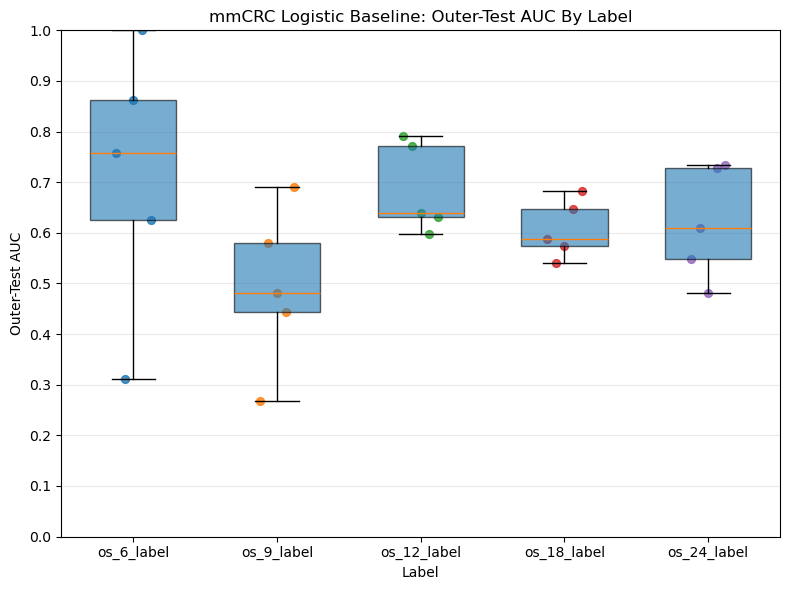

In [8]:
import matplotlib.pyplot as plt

if classification_outer_df.empty:
    raise ValueError('classification_outer_df is empty. Run the classification section first.')

plot_df = classification_outer_df[['target', 'outer_fold', 'auc']].copy()
target_order = [target for target in CLASSIFICATION_TARGETS if target in plot_df['target'].unique()]
boxplot_data = [
    plot_df.loc[plot_df['target'] == target, 'auc'].to_numpy(dtype=float)
    for target in target_order
]

print('=== Outer-test AUC values by label ===')
display(plot_df.sort_values(['target', 'outer_fold']).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(max(8, len(target_order) * 1.6), 6))
bp = ax.boxplot(boxplot_data, tick_labels=target_order, patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_alpha(0.6)

for x_pos, target in enumerate(target_order, start=1):
    y = plot_df.loc[plot_df['target'] == target, 'auc'].to_numpy(dtype=float)
    if len(y) == 0:
        continue
    jitter = np.linspace(-0.12, 0.12, num=len(y)) if len(y) > 1 else np.array([0.0])
    ax.scatter(np.full(len(y), x_pos) + jitter, y, alpha=0.8, s=32)

ax.set_title('mmCRC Logistic Baseline: Outer-Test AUC By Label')
ax.set_xlabel('Label')
ax.set_ylabel('Outer-Test AUC')
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()

figures_dir = Path.cwd() / 'figures' if Path.cwd().name == 'data_exploration' else Path.cwd() / 'data_exploration' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
figure_path = figures_dir / 'mmcrc_best_endpoints_outer_auc_boxplot.png'
plt.savefig(figure_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {figure_path}')
plt.show()
